In [1]:
# To run shell commands in Colab
%%bash
set -e

# 1. Install dependencies
apt-get update -y
apt-get install -y gnupg2 curl build-essential

# 2. Import RVM signing keys
gpg2 --keyserver hkp://keyserver.ubuntu.com --recv-keys \
  409B6B1796C275462A1703113804BB82D39DC0E3 \
  7D2BAF1CF37B13E2069D6956105BD0E739499BDB || \
  (curl -sSL https://rvm.io/mpapis.asc | gpg2 --import - && \
   curl -sSL https://rvm.io/pkuczynski.asc | gpg2 --import -)

# 3. Install RVM
curl -sSL https://get.rvm.io | bash -s stable

# 4. Load RVM for this script
source /etc/profile.d/rvm.sh

# 5. Install Ruby 3.3.4 (>= 3.1 required by aspera-cli)
rvm install 3.3.4
rvm use 3.3.4 --default

# 6. Show Ruby version
ruby -v

# 7. Install aspera-cli
gem install aspera-cli

# 8. Show ascli version
ascli --version

# 9. Let ascli install its SDK and ascp client
ascli conf ascp install

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,633 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,205 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [69.2 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,966 kB

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
gpg: directory '/root/.gnupg' created
gpg: keybox '/root/.gnupg/pubring.kbx' created
gpg: key 105BD0E739499BDB: 2 duplicate signatures removed
gpg: /root/.gnupg/trustdb.gpg: trustdb created
gpg: key 105BD0E739499BDB: public key "Piotr Kuczynski <piotr.kuczynski@gmail.com>" imported
gpg: key 3804BB82D39DC0E3: public key "Michal Papis (RVM signing) <mpapis@gmail.com>" imported
gpg: Total number processed: 2
gpg:               imported: 2
gpg: Signature made Fri 15 Jan 2021 06:46:22 PM UTC
gpg:                using RSA key 7D2BAF1CF37B13E2069D6956105BD0E739499BDB
gpg: Good signature from "Piotr Kuczynski <piotr.kuczynski@gmail.com>" [unknown]
gpg: WARNING: This key is not certified with a trusted signature!
gpg:          There is no indication that the signature belongs to the owner.
Primary key fingerp

This is for downloading entire dataset, it's SLOW

In [2]:
# To run shell commands in Colab
#%%bash
#set -e

# Load RVM + Ruby 3.3.4 in this shell -- each cell in Colab is a new shell
#source /etc/profile.d/rvm.sh
#rvm use 3.3.4 >/dev/null

# the actual ascli "receive" command with our package URL from above
#ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex/public/package?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==&redirected=true&authenticated=true'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Instead, we can download specific folders like below

In [3]:
# To run shell commands in Colab
%%bash
set -e

# Load RVM + Ruby 3.3.4 in this shell -- each cell in Colab is a new shell
source /etc/profile.d/rvm.sh
rvm use 3.3.4 >/dev/null

# the actual ascli "receive" command with our package URL from above
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0009_nifti/UCSF-PDGM-0009_ADC.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0009_nifti/UCSF-PDGM-0009_T1.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0009_nifti/UCSF-PDGM-0009_T2.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0009_nifti/UCSF-PDGM-0009_tumor_segmentation.nii.gz

ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0014_nifti/UCSF-PDGM-0014_ADC.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0014_nifti/UCSF-PDGM-0014_T1.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0014_nifti/UCSF-PDGM-0014_T2.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0014_nifti/UCSF-PDGM-0014_tumor_segmentation.nii.gz

ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0015_nifti/UCSF-PDGM-0015_ADC.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0015_nifti/UCSF-PDGM-0015_T1.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0015_nifti/UCSF-PDGM-0015_T2.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0015_nifti/UCSF-PDGM-0015_tumor_segmentation.nii.gz

ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0010_nifti/UCSF-PDGM-0010_ADC.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0010_nifti/UCSF-PDGM-0010_T1.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0010_nifti/UCSF-PDGM-0010_T2.nii.gz
ascli faspex5 packages receive --url='https://faspex.cancerimagingarchive.net/aspera/faspex?context=eyJyZXNvdXJjZSI6InBhY2thZ2VzIiwidHlwZSI6ImV4dGVybmFsX2Rvd25sb2FkX3BhY2thZ2UiLCJpZCI6IjEwNjUiLCJwYXNzY29kZSI6IjYxZmRlZDkzYzYzM2JhODIxNWYwZjBjMDU2YWRiNjk3Y2IwOTM4MDIiLCJwYWNrYWdlX2lkIjoiMTA2NSIsImVtYWlsIjoiaGVscEBjYW5jZXJpbWFnaW5nYXJjaGl2ZS5uZXQifQ==' UCSF-PDGM-v5/UCSF-PDGM-0010_nifti/UCSF-PDGM-0010_tumor_segmentation.nii.gz

Receiving package 1065
+---------+---------+
| package | status  |
+---------+---------+
| 1065    | success |
+---------+---------+
Receiving package 1065
+---------+---------+
| package | status  |
+---------+---------+
| 1065    | success |
+---------+---------+
Receiving package 1065
+---------+---------+
| package | status  |
+---------+---------+
| 1065    | success |
+---------+---------+
Receiving package 1065
+---------+---------+
| package | status  |
+---------+---------+
| 1065    | success |
+---------+---------+
Receiving package 1065
+---------+---------+
| package | status  |
+---------+---------+
| 1065    | success |
+---------+---------+
Receiving package 1065
+---------+---------+
| package | status  |
+---------+---------+
| 1065    | success |
+---------+---------+
Receiving package 1065
+---------+---------+
| package | status  |
+---------+---------+
| 1065    | success |
+---------+---------+
Receiving package 1065
+---------+---------+
| package | status  |
+-


--- ADC values inside tumor (scaled) ---
count_voxels: 117717
mean_mm2_s: 1.13 x10^-3 mm^2/s
median_mm2_s: 1.10 x10^-3 mm^2/s
voxel_size_mm: (1.0, 1.0, 1.0)
tumor_volume_mm3: 117717.0
tumor_volume_ml: 117.717


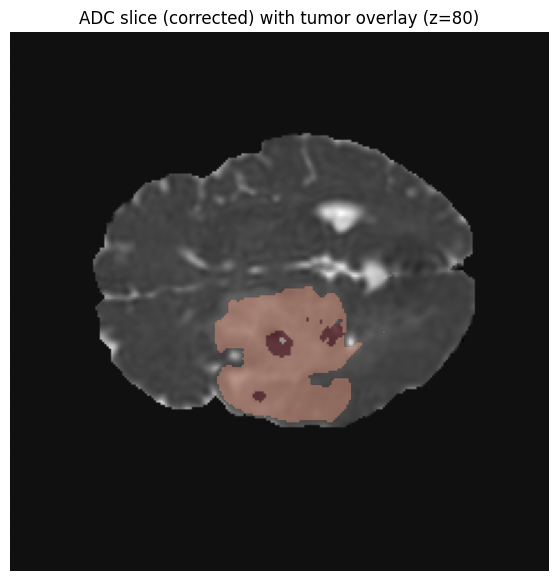

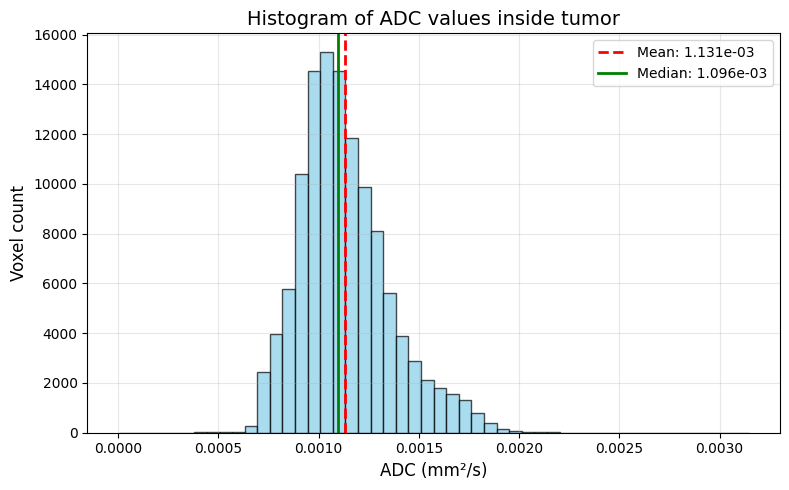

In [ ]:

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

adc_path  = "/content/UCSF-PDGM-0010_ADC.nii.gz"
mask_path = "/content/UCSF-PDGM-0010_tumor_segmentation.nii.gz"

adc_img = nib.load(adc_path)
mask_img = nib.load(mask_path)
adc = adc_img.get_fdata().astype(np.float32)
mask = mask_img.get_fdata()
mask_bin = (mask > 0).astype(np.uint8)

if adc.shape != mask_bin.shape:
    raise RuntimeError(f"Shapes differ: ADC {adc.shape} vs MASK {mask_bin.shape}")

num_vox = int(np.sum(mask_bin > 0))
if num_vox == 0:
    raise RuntimeError("no voxels > 0")

tumor_vals = adc[mask_bin > 0]
tumor_vals = np.abs(adc[mask_bin > 0])


stats = {
    "count_voxels": int(tumor_vals.size),
    "mean_mm2_s": float(np.mean(tumor_vals)),
    "median_mm2_s": float(np.median(tumor_vals)),
}

voxel_size_mm = adc_img.header.get_zooms()[:3]
vox_vol_mm3 = float(voxel_size_mm[0] * voxel_size_mm[1] * voxel_size_mm[2])
tumor_vol_mm3 = stats["count_voxels"] * vox_vol_mm3
stats["voxel_size_mm"] = tuple(float(x) for x in voxel_size_mm)
stats["tumor_volume_mm3"] = tumor_vol_mm3
stats["tumor_volume_ml"] = tumor_vol_mm3 / 1000.0

print("\n--- ADC values inside tumor (scaled) ---")
for k, v in stats.items():
    if "mm2_s" in k:
        print(f"{k}: {v*1e3:.2f} x10^-3 mm^2/s")
    else:
        print(f"{k}: {v}")

coords = np.array(np.where(mask > 0))
z_center = int(np.median(coords[2]))

slice_adc  = adc[:, :, z_center]
slice_mask = mask[:, :, z_center]

slice_adc_corrected  = slice_adc[::-1, :]
slice_mask_corrected = slice_mask[::-1, :]

plt.figure(figsize=(7,7))

plt.imshow(slice_adc_corrected, cmap='gray', origin='lower')

plt.imshow(np.ma.masked_where(slice_mask_corrected == 0, slice_mask_corrected),
           cmap='Reds', alpha=0.4, origin='lower')

plt.title(f"ADC slice (corrected) with tumor overlay (z={z_center})")
plt.axis('off')
plt.figure(figsize=(8,5))
plt.hist(tumor_vals.flatten(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(np.mean(tumor_vals), color='red', linestyle='--', linewidth=2, label=f"Mean: {np.mean(tumor_vals):.3e}")

plt.axvline(np.median(tumor_vals), color='green', linestyle='-', linewidth=2, label=f"Median: {np.median(tumor_vals):.3e}")

plt.xlabel("ADC (mm²/s)", fontsize=12)
plt.ylabel("Voxel count", fontsize=12)
plt.title("Histogram of ADC values inside tumor", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ADC reference ranges
# ------------------------------------------------------------
# Normal brain tissue:
###   White matter / Grey matter: ADC ≈ 0.7 – 0.9 × 10^-3 mm²/s
#
# Brain tumors:
###   Low-grade gliomas: ≈ 1.2 – 1.5 × 10^-3 mm²/s
###   High-grade gliomas: ≈ 0.8 – 1.2 × 10^-3 mm²/s (lower due to high cellularity)
###   Metastases: ≈ 0.9 – 1.3 × 10^-3 mm²/s (varies by tumor type)
